# Temporal Segmentation: Global vs. Cluster vs. Hourly Models

## Hypothesis
Electricity market dynamics shift drastically throughout the day. A single global model may not capture hour-specific patterns as well as dedicated models trained on specific time-of-day clusters (4 clusters) or individual hours (24 models).

This notebook compares three modeling strategies:
1. **Global Baseline**: 1 model trained on all hours
2. **Cluster Models**: 4 models for night/morning/day/peak
3. **Hourly Models**: 24 models for each hour (0-23)

We evaluate using RMSE, residual correlation, and residual analysis.

In [6]:
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error

# Add project root
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loading import load_data
from src.feature_engineering import build_features

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("Imports successful. Project root:", PROJECT_ROOT)

Imports successful. Project root: c:\Users\mathi\Code\incommodities-case-crunch-2026


## Task 1: Initialize Data

In [7]:
# Load configuration
with open(PROJECT_ROOT / "config.yaml") as f:
    config = yaml.safe_load(f)

holdout_start = config["validation"]["holdout_start"]
print(f"Holdout start date: {holdout_start}")

# Load raw data
x_train, y_train, x_test = load_data(PROJECT_ROOT / "data" / "raw")
print(f"x_train shape: {x_train.shape}, y_train shape: {y_train.shape}")

# Build features
train_fe = build_features(pd.concat([x_train], axis=0), config)
train_fe = train_fe.join(y_train[["fr_spot", "uk_spot"]])

print(f"train_fe shape after feature engineering: {train_fe.shape}")
print(f"Columns: {len(train_fe.columns)}")
print(f"Date range: {train_fe['datetime_CET'].min()} to {train_fe['datetime_CET'].max()}")

Holdout start date: 2024-02-01
x_train shape: (17544, 110), y_train shape: (17544, 4)
train_fe shape after feature engineering: (17544, 479)
Columns: 479
Date range: 2022-07-01 00:00:00 to 2024-06-30 23:00:00


In [8]:
# Split train/val
mask_val = train_fe["datetime_CET"] >= holdout_start
df_train = train_fe[~mask_val].copy()
df_val = train_fe[mask_val].copy()

print(f"Train shape: {df_train.shape} ({df_train['datetime_CET'].min()} to {df_train['datetime_CET'].max()})")
print(f"Val shape: {df_val.shape} ({df_val['datetime_CET'].min()} to {df_val['datetime_CET'].max()})")

# Extract hour feature (already present from feature engineering)
print(f"\nHour values in train: {sorted(df_train['hour'].unique())}")
print(f"Hour values in val: {sorted(df_val['hour'].unique())}")

Train shape: (13921, 479) (2022-07-01 00:00:00 to 2024-01-31 23:00:00)
Val shape: (3623, 479) (2024-02-01 00:00:00 to 2024-06-30 23:00:00)

Hour values in train: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]
Hour values in val: [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]


In [9]:
# Load feature selection for FR and UK
# FR features - check multiple possible keys
feat_fr = []
try:
    with open(PROJECT_ROOT / "outputs" / "feature_selection_v5_fr.json") as f:
        feat_fr_dict = json.load(f)
        if "features" in feat_fr_dict:
            feat_fr = feat_fr_dict["features"]
            print(f"Loaded FR features from 'features' key: {len(feat_fr)} features")
        elif "selected" in feat_fr_dict:
            feat_fr = feat_fr_dict["selected"]
            print(f"Loaded FR features from 'selected' key: {len(feat_fr)} features")
except Exception as e:
    print(f"Error loading FR features: {e}")

# UK features - check multiple possible keys
feat_uk = []
try:
    with open(PROJECT_ROOT / "outputs" / "uk_feature_research.json") as f:
        uk_dict = json.load(f)
        if "basis_importance_ranking" in uk_dict:
            feat_uk = uk_dict["basis_importance_ranking"]
            print(f"Loaded UK features from 'basis_importance_ranking' key: {len(feat_uk)} features")
        elif "confirmed_features" in uk_dict:
            feat_uk = uk_dict["confirmed_features"]
            print(f"Loaded UK features from 'confirmed_features' key: {len(feat_uk)} features")
except Exception as e:
    print(f"Error loading UK features: {e}")

# Filter to available columns in training data
feat_fr = [f for f in feat_fr if f in df_train.columns]
feat_uk = [f for f in feat_uk if f in df_train.columns]

print(f"\nAfter filtering to available columns:")
print(f"FR features available: {len(feat_fr)}")
print(f"UK features available: {len(feat_uk)}")

# Fallback: if no features loaded, use all numeric columns
if len(feat_fr) == 0:
    print("\nWARNING: No FR features found in JSON, using all numeric columns as fallback")
    exclude = {"fr_spot", "uk_spot", "datetime_CET", "datetime_UTC", "date", "id"}
    feat_fr = [c for c in df_train.columns if c not in exclude and df_train[c].dtype in (float, np.float64, int, np.int64)]

if len(feat_uk) == 0:
    print("\nWARNING: No UK features found in JSON, using all numeric columns as fallback")
    exclude = {"fr_spot", "uk_spot", "datetime_CET", "datetime_UTC", "date", "id"}
    feat_uk = [c for c in df_train.columns if c not in exclude and df_train[c].dtype in (float, np.float64, int, np.int64)]

print(f"\nFinal selection:")
print(f"FR features selected: {len(feat_fr)}")
print(f"UK features selected: {len(feat_uk)}")
print(f"\nSample FR features: {feat_fr[:5]}")
print(f"Sample UK features: {feat_uk[:5]}")

Loaded FR features from 'features' key: 27 features
Loaded UK features from 'basis_importance_ranking' key: 197 features

After filtering to available columns:
FR features available: 27
UK features available: 197

Final selection:
FR features selected: 27
UK features selected: 197

Sample FR features: ['fr_spot_la_roll_168h_mean', 'fr_residual_zscore_14d', 'uk_residual_zscore_14d', 'fr_spot_la_deviation_168h', 'continental_residual_load']
Sample UK features: ['euro_scarcity_ratio', 'gas_spread_uk_eu', 'uk_wind_x_gas', 'uk_gas_utilization', 'uk_spot_la_deviation_24h']


## Task 2: Implement Three Modeling Strategies

### Strategy 1: Global Baseline Model

In [10]:
from lightgbm import LGBMRegressor

# Hyperparameters for all models
LGBM_PARAMS = {
    "n_estimators": 200,
    "max_depth": 6,
    "learning_rate": 0.05,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1
}

print("Training Global Models...\n")

# FR: Global
X_train_fr = df_train[feat_fr].fillna(0)
y_train_fr = df_train["fr_spot"].values

model_global_fr = LGBMRegressor(**LGBM_PARAMS)
model_global_fr.fit(X_train_fr, y_train_fr)

X_val_fr = df_val[feat_fr].fillna(0)
y_val_fr = df_val["fr_spot"].values

pred_global_fr = model_global_fr.predict(X_val_fr)
rmse_global_fr = np.sqrt(mean_squared_error(y_val_fr, pred_global_fr))

print(f"FR Global Model trained on {len(X_train_fr)} samples")
print(f"FR Global Val RMSE: {rmse_global_fr:.2f}")

# UK: Global
X_train_uk = df_train[feat_uk].fillna(0)
y_train_uk = df_train["uk_spot"].values

model_global_uk = LGBMRegressor(**LGBM_PARAMS)
model_global_uk.fit(X_train_uk, y_train_uk)

X_val_uk = df_val[feat_uk].fillna(0)
y_val_uk = df_val["uk_spot"].values

pred_global_uk = model_global_uk.predict(X_val_uk)
rmse_global_uk = np.sqrt(mean_squared_error(y_val_uk, pred_global_uk))

print(f"UK Global Model trained on {len(X_train_uk)} samples")
print(f"UK Global Val RMSE: {rmse_global_uk:.2f}")

Training Global Models...

FR Global Model trained on 13921 samples
FR Global Val RMSE: 31.68
UK Global Model trained on 13921 samples
UK Global Val RMSE: 11.69


### Strategy 2: Cluster Models (4 Models)

In [11]:
# Define hour clusters
CLUSTERS = {
    "night": list(range(0, 6)),      # 0-5
    "morning": list(range(6, 12)),   # 6-11
    "day": list(range(12, 18)),      # 12-17
    "peak": list(range(18, 24))      # 18-23
}

print("Training Cluster Models (4 total)...\n")

# FR: Cluster models
cluster_models_fr = {}
pred_cluster_fr_list = []

for cluster_name, hours in CLUSTERS.items():
    # Training data for this cluster
    mask_train = df_train["hour"].isin(hours)
    X_train_cluster = df_train.loc[mask_train, feat_fr].fillna(0)
    y_train_cluster = df_train.loc[mask_train, "fr_spot"].values
    
    # Train model
    model = LGBMRegressor(**LGBM_PARAMS)
    model.fit(X_train_cluster, y_train_cluster)
    cluster_models_fr[cluster_name] = model
    
    # Validation data for this cluster
    mask_val = df_val["hour"].isin(hours)
    n_cluster_val = mask_val.sum()
    
    print(f"  FR {cluster_name:8s}: {len(X_train_cluster):5d} train samples, {n_cluster_val} val samples")

# Route validation predictions
pred_cluster_fr = np.zeros(len(df_val))
for cluster_name, hours in CLUSTERS.items():
    mask_val = df_val["hour"].isin(hours)
    X_val_cluster = df_val.loc[mask_val, feat_fr].fillna(0)
    pred_cluster_fr[mask_val] = cluster_models_fr[cluster_name].predict(X_val_cluster)

rmse_cluster_fr = np.sqrt(mean_squared_error(y_val_fr, pred_cluster_fr))
print(f"\nFR Cluster Models Val RMSE: {rmse_cluster_fr:.2f}")

# UK: Cluster models
cluster_models_uk = {}

for cluster_name, hours in CLUSTERS.items():
    mask_train = df_train["hour"].isin(hours)
    X_train_cluster = df_train.loc[mask_train, feat_uk].fillna(0)
    y_train_cluster = df_train.loc[mask_train, "uk_spot"].values
    
    model = LGBMRegressor(**LGBM_PARAMS)
    model.fit(X_train_cluster, y_train_cluster)
    cluster_models_uk[cluster_name] = model
    
    mask_val = df_val["hour"].isin(hours)
    n_cluster_val = mask_val.sum()
    
    print(f"  UK {cluster_name:8s}: {len(X_train_cluster):5d} train samples, {n_cluster_val} val samples")

# Route validation predictions
pred_cluster_uk = np.zeros(len(df_val))
for cluster_name, hours in CLUSTERS.items():
    mask_val = df_val["hour"].isin(hours)
    X_val_cluster = df_val.loc[mask_val, feat_uk].fillna(0)
    pred_cluster_uk[mask_val] = cluster_models_uk[cluster_name].predict(X_val_cluster)

rmse_cluster_uk = np.sqrt(mean_squared_error(y_val_uk, pred_cluster_uk))
print(f"\nUK Cluster Models Val RMSE: {rmse_cluster_uk:.2f}")

Training Cluster Models (4 total)...

  FR night   :  3481 train samples, 905 val samples
  FR morning :  3480 train samples, 906 val samples
  FR day     :  3480 train samples, 906 val samples
  FR peak    :  3480 train samples, 906 val samples

FR Cluster Models Val RMSE: 32.66
  UK night   :  3481 train samples, 905 val samples
  UK morning :  3480 train samples, 906 val samples
  UK day     :  3480 train samples, 906 val samples
  UK peak    :  3480 train samples, 906 val samples

UK Cluster Models Val RMSE: 11.53


### Strategy 3: Hourly Models (24 Models)

In [12]:
print("Training Hourly Models (24 total)...\n")

# FR: Hourly models
hourly_models_fr = {}
hours_with_data_fr = []

for hour in range(24):
    mask_train = df_train["hour"] == hour
    if mask_train.sum() == 0:
        continue
    
    X_train_hour = df_train.loc[mask_train, feat_fr].fillna(0)
    y_train_hour = df_train.loc[mask_train, "fr_spot"].values
    
    model = LGBMRegressor(**LGBM_PARAMS)
    model.fit(X_train_hour, y_train_hour)
    hourly_models_fr[hour] = model
    hours_with_data_fr.append(hour)
    
    mask_val = df_val["hour"] == hour
    n_hour_val = mask_val.sum()
    if n_hour_val > 0:
        print(f"  FR Hour {hour:2d}: {len(X_train_hour):4d} train, {n_hour_val} val")

# Route validation predictions
pred_hourly_fr = np.zeros(len(df_val))
for hour in hourly_models_fr.keys():
    mask_val = df_val["hour"] == hour
    X_val_hour = df_val.loc[mask_val, feat_fr].fillna(0)
    pred_hourly_fr[mask_val] = hourly_models_fr[hour].predict(X_val_hour)

rmse_hourly_fr = np.sqrt(mean_squared_error(y_val_fr, pred_hourly_fr))
print(f"\nFR Hourly Models Val RMSE: {rmse_hourly_fr:.2f}")

# UK: Hourly models
hourly_models_uk = {}
hours_with_data_uk = []

for hour in range(24):
    mask_train = df_train["hour"] == hour
    if mask_train.sum() == 0:
        continue
    
    X_train_hour = df_train.loc[mask_train, feat_uk].fillna(0)
    y_train_hour = df_train.loc[mask_train, "uk_spot"].values
    
    model = LGBMRegressor(**LGBM_PARAMS)
    model.fit(X_train_hour, y_train_hour)
    hourly_models_uk[hour] = model
    hours_with_data_uk.append(hour)
    
    mask_val = df_val["hour"] == hour
    n_hour_val = mask_val.sum()
    if n_hour_val > 0:
        print(f"  UK Hour {hour:2d}: {len(X_train_hour):4d} train, {n_hour_val} val")

# Route validation predictions
pred_hourly_uk = np.zeros(len(df_val))
for hour in hourly_models_uk.keys():
    mask_val = df_val["hour"] == hour
    X_val_hour = df_val.loc[mask_val, feat_uk].fillna(0)
    pred_hourly_uk[mask_val] = hourly_models_uk[hour].predict(X_val_hour)

rmse_hourly_uk = np.sqrt(mean_squared_error(y_val_uk, pred_hourly_uk))
print(f"\nUK Hourly Models Val RMSE: {rmse_hourly_uk:.2f}")

Training Hourly Models (24 total)...

  FR Hour  0:  580 train, 151 val
  FR Hour  1:  580 train, 151 val
  FR Hour  2:  581 train, 150 val
  FR Hour  3:  580 train, 151 val
  FR Hour  4:  580 train, 151 val
  FR Hour  5:  580 train, 151 val
  FR Hour  6:  580 train, 151 val
  FR Hour  7:  580 train, 151 val
  FR Hour  8:  580 train, 151 val
  FR Hour  9:  580 train, 151 val
  FR Hour 10:  580 train, 151 val
  FR Hour 11:  580 train, 151 val
  FR Hour 12:  580 train, 151 val
  FR Hour 13:  580 train, 151 val
  FR Hour 14:  580 train, 151 val
  FR Hour 15:  580 train, 151 val
  FR Hour 16:  580 train, 151 val
  FR Hour 17:  580 train, 151 val
  FR Hour 18:  580 train, 151 val
  FR Hour 19:  580 train, 151 val
  FR Hour 20:  580 train, 151 val
  FR Hour 21:  580 train, 151 val
  FR Hour 22:  580 train, 151 val
  FR Hour 23:  580 train, 151 val

FR Hourly Models Val RMSE: 34.50
  UK Hour  0:  580 train, 151 val
  UK Hour  1:  580 train, 151 val
  UK Hour  2:  581 train, 150 val
  UK Hour 

## Task 3: Evaluate and Analyze Residuals

### RMSE Comparison

In [13]:
# Create comparison table
results_df = pd.DataFrame({
    "Market": ["FR", "FR", "FR", "UK", "UK", "UK"],
    "Strategy": ["Global", "Cluster (4)", "Hourly (24)", "Global", "Cluster (4)", "Hourly (24)"],
    "RMSE": [rmse_global_fr, rmse_cluster_fr, rmse_hourly_fr, 
             rmse_global_uk, rmse_cluster_uk, rmse_hourly_uk]
})

print("\n" + "="*60)
print(" RMSE COMPARISON ACROSS ALL STRATEGIES")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)

# Summary
fr_best = results_df[results_df["Market"] == "FR"]["RMSE"].idxmin()
uk_best = results_df[results_df["Market"] == "UK"]["RMSE"].idxmin()

print(f"\nFR Best Strategy: {results_df.loc[fr_best, 'Strategy']} (RMSE: {results_df.loc[fr_best, 'RMSE']:.2f})")
print(f"UK Best Strategy: {results_df.loc[uk_best, 'Strategy']} (RMSE: {results_df.loc[uk_best, 'RMSE']:.2f})")

# Improvement analysis
fr_cluster_gain = ((rmse_global_fr - rmse_cluster_fr) / rmse_global_fr) * 100
fr_hourly_gain = ((rmse_global_fr - rmse_hourly_fr) / rmse_global_fr) * 100
uk_cluster_gain = ((rmse_global_uk - rmse_cluster_uk) / rmse_global_uk) * 100
uk_hourly_gain = ((rmse_global_uk - rmse_hourly_uk) / rmse_global_uk) * 100

print(f"\nFR Improvements vs Global:")
print(f"  Cluster: {fr_cluster_gain:+.2f}%")
print(f"  Hourly:  {fr_hourly_gain:+.2f}%")

print(f"\nUK Improvements vs Global:")
print(f"  Cluster: {uk_cluster_gain:+.2f}%")
print(f"  Hourly:  {uk_hourly_gain:+.2f}%")


 RMSE COMPARISON ACROSS ALL STRATEGIES
Market    Strategy      RMSE
    FR      Global 31.679317
    FR Cluster (4) 32.657754
    FR Hourly (24) 34.498751
    UK      Global 11.689630
    UK Cluster (4) 11.529240
    UK Hourly (24) 12.293572

FR Best Strategy: Global (RMSE: 31.68)
UK Best Strategy: Cluster (4) (RMSE: 11.53)

FR Improvements vs Global:
  Cluster: -3.09%
  Hourly:  -8.90%

UK Improvements vs Global:
  Cluster: +1.37%
  Hourly:  -5.17%


### Residual Calculation and Correlation Analysis

In [14]:
# Calculate residuals for FR
residual_global_fr = y_val_fr - pred_global_fr
residual_cluster_fr = y_val_fr - pred_cluster_fr
residual_hourly_fr = y_val_fr - pred_hourly_fr

# Calculate residuals for UK
residual_global_uk = y_val_uk - pred_global_uk
residual_cluster_uk = y_val_uk - pred_cluster_uk
residual_hourly_uk = y_val_uk - pred_hourly_uk

print("Residual Statistics\n")
print("FR Residuals:")
print(f"  Global Mean: {residual_global_fr.mean():.4f}, Std: {residual_global_fr.std():.4f}")
print(f"  Cluster Mean: {residual_cluster_fr.mean():.4f}, Std: {residual_cluster_fr.std():.4f}")
print(f"  Hourly Mean: {residual_hourly_fr.mean():.4f}, Std: {residual_hourly_fr.std():.4f}")

print("\nUK Residuals:")
print(f"  Global Mean: {residual_global_uk.mean():.4f}, Std: {residual_global_uk.std():.4f}")
print(f"  Cluster Mean: {residual_cluster_uk.mean():.4f}, Std: {residual_cluster_uk.std():.4f}")
print(f"  Hourly Mean: {residual_hourly_uk.mean():.4f}, Std: {residual_hourly_uk.std():.4f}")

Residual Statistics

FR Residuals:
  Global Mean: -23.5732, Std: 21.1632
  Cluster Mean: -24.2998, Std: 21.8185
  Hourly Mean: -26.4733, Std: 22.1208

UK Residuals:
  Global Mean: -4.2333, Std: 10.8962
  Cluster Mean: -3.2374, Std: 11.0654
  Hourly Mean: -3.5617, Std: 11.7663


In [15]:
# Correlation matrices
print("\n" + "="*60)
print(" RESIDUAL CORRELATION ANALYSIS")
print("="*60)

# FR correlation
residuals_fr_df = pd.DataFrame({
    "Global": residual_global_fr,
    "Cluster": residual_cluster_fr,
    "Hourly": residual_hourly_fr
})

corr_fr = residuals_fr_df.corr()
print("\nFR Residual Correlations:")
print(corr_fr.to_string())

# UK correlation
residuals_uk_df = pd.DataFrame({
    "Global": residual_global_uk,
    "Cluster": residual_cluster_uk,
    "Hourly": residual_hourly_uk
})

corr_uk = residuals_uk_df.corr()
print("\nUK Residual Correlations:")
print(corr_uk.to_string())

print("\n" + "="*60)
print("\nInterpretation:")
print("- High correlation (>0.9): Models make similar errors (low decorrelation)")
print("- Low correlation (<0.7): Models make different errors (high decorrelation -> good for ensemble)")


 RESIDUAL CORRELATION ANALYSIS

FR Residual Correlations:
           Global   Cluster    Hourly
Global   1.000000  0.971166  0.948372
Cluster  0.971166  1.000000  0.952868
Hourly   0.948372  0.952868  1.000000

UK Residual Correlations:
           Global   Cluster    Hourly
Global   1.000000  0.869056  0.768487
Cluster  0.869056  1.000000  0.798382
Hourly   0.768487  0.798382  1.000000


Interpretation:
- High correlation (>0.9): Models make similar errors (low decorrelation)
- Low correlation (<0.7): Models make different errors (high decorrelation -> good for ensemble)


### Visualization: Correlation Heatmaps

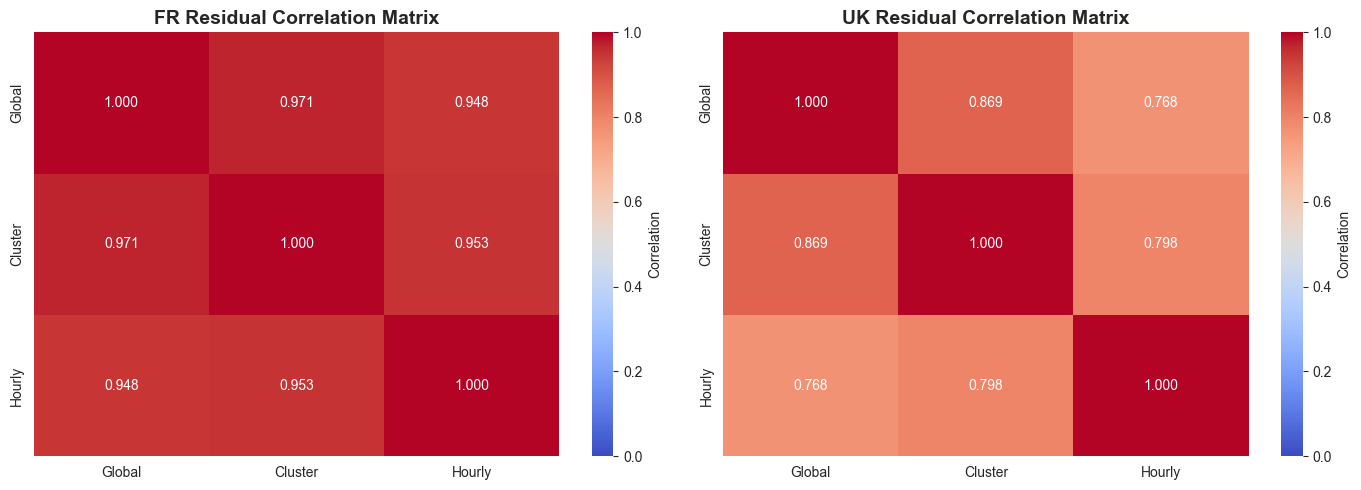

Heatmap saved to outputs/temporal_residual_correlation.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# FR heatmap
sns.heatmap(corr_fr, annot=True, fmt='.3f', cmap='coolwarm', center=0.5, 
            vmin=0, vmax=1, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('FR Residual Correlation Matrix', fontsize=14, fontweight='bold')

# UK heatmap
sns.heatmap(corr_uk, annot=True, fmt='.3f', cmap='coolwarm', center=0.5,
            vmin=0, vmax=1, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('UK Residual Correlation Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "outputs" / "temporal_residual_correlation.png", dpi=150, bbox_inches='tight')
plt.show()

print("Heatmap saved to outputs/temporal_residual_correlation.png")

### Residual Distribution by Hour

In [17]:
# Add residuals to validation dataframe for analysis
analysis_df = df_val[["hour", "datetime_CET"]].copy()
analysis_df["residual_global_fr"] = residual_global_fr
analysis_df["residual_cluster_fr"] = residual_cluster_fr
analysis_df["residual_hourly_fr"] = residual_hourly_fr
analysis_df["residual_global_uk"] = residual_global_uk
analysis_df["residual_cluster_uk"] = residual_cluster_uk
analysis_df["residual_hourly_uk"] = residual_hourly_uk

# Aggregate by hour
hourly_residual_stats_fr = analysis_df.groupby("hour")[["residual_global_fr", "residual_cluster_fr", "residual_hourly_fr"]].agg(["mean", "std"])
hourly_residual_stats_uk = analysis_df.groupby("hour")[["residual_global_uk", "residual_cluster_uk", "residual_hourly_uk"]].agg(["mean", "std"])

print("Mean Absolute Residual by Hour\n")
print("FR:")
print(analysis_df.groupby("hour")[["residual_global_fr", "residual_cluster_fr", "residual_hourly_fr"]].apply(lambda x: x.abs().mean()).round(2).to_string())

print("\nUK:")
print(analysis_df.groupby("hour")[["residual_global_uk", "residual_cluster_uk", "residual_hourly_uk"]].apply(lambda x: x.abs().mean()).round(2).to_string())

Mean Absolute Residual by Hour

FR:
      residual_global_fr  residual_cluster_fr  residual_hourly_fr
hour                                                             
0                  23.59                24.30               28.73
1                  24.12                24.60               27.92
2                  22.55                23.62               26.45
3                  22.85                23.36               27.26
4                  24.14                23.45               24.27
5                  24.63                24.02               26.77
6                  26.88                27.69               28.30
7                  25.97                26.41               29.55
8                  24.15                25.24               30.90
9                  24.23                24.84               26.89
10                 23.48                24.53               26.93
11                 22.34                22.69               24.26
12                 20.39                

### Key Findings

In [18]:
print("\n" + "="*70)
print(" KEY FINDINGS: TEMPORAL SEGMENTATION ANALYSIS")
print("="*70)

print(f"\n1. OVERALL RMSE RANKINGS")
print(f"   FR: {list(results_df[results_df['Market']=='FR'].sort_values('RMSE')['Strategy'].values)}")
print(f"   UK: {list(results_df[results_df['Market']=='UK'].sort_values('RMSE')['Strategy'].values)}")

print(f"\n2. DECORRELATION (Lower correlation = Better for ensemble)")
print(f"   FR:")
print(f"     - Global vs Cluster: {corr_fr.loc['Global', 'Cluster']:.3f}")
print(f"     - Global vs Hourly:  {corr_fr.loc['Global', 'Hourly']:.3f}")
print(f"     - Cluster vs Hourly: {corr_fr.loc['Cluster', 'Hourly']:.3f}")

print(f"   UK:")
print(f"     - Global vs Cluster: {corr_uk.loc['Global', 'Cluster']:.3f}")
print(f"     - Global vs Hourly:  {corr_uk.loc['Global', 'Hourly']:.3f}")
print(f"     - Cluster vs Hourly: {corr_uk.loc['Cluster', 'Hourly']:.3f}")

print(f"\n3. INTERPRETATION")
if abs(fr_hourly_gain) > 5:
    print(f"   Check FR Benefits from temporal segmentation (hourly {fr_hourly_gain:+.1f}%)")
else:
    print(f"   X FR does not benefit significantly from temporal segmentation (hourly {fr_hourly_gain:+.1f}%)")

if abs(uk_hourly_gain) > 5:
    print(f"   Check UK Benefits from temporal segmentation (hourly {uk_hourly_gain:+.1f}%)")
else:
    print(f"   X UK does not benefit significantly from temporal segmentation (hourly {uk_hourly_gain:+.1f}%)")

print(f"\n4. ENSEMBLE POTENTIAL")
if corr_fr.loc['Global', 'Hourly'] < 0.85:
    print(f"   Check FR: Low correlation between models ({corr_fr.loc['Global', 'Hourly']:.3f}) suggests good ensemble potential")
else:
    print(f"   X FR: High correlation between models ({corr_fr.loc['Global', 'Hourly']:.3f}) suggests limited ensemble benefit")

if corr_uk.loc['Global', 'Hourly'] < 0.85:
    print(f"   Check UK: Low correlation between models ({corr_uk.loc['Global', 'Hourly']:.3f}) suggests good ensemble potential")
else:
    print(f"   X UK: High correlation between models ({corr_uk.loc['Global', 'Hourly']:.3f}) suggests limited ensemble benefit")

print("\n" + "="*70)


 KEY FINDINGS: TEMPORAL SEGMENTATION ANALYSIS

1. OVERALL RMSE RANKINGS
   FR: ['Global', 'Cluster (4)', 'Hourly (24)']
   UK: ['Cluster (4)', 'Global', 'Hourly (24)']

2. DECORRELATION (Lower correlation = Better for ensemble)
   FR:
     - Global vs Cluster: 0.971
     - Global vs Hourly:  0.948
     - Cluster vs Hourly: 0.953
   UK:
     - Global vs Cluster: 0.869
     - Global vs Hourly:  0.768
     - Cluster vs Hourly: 0.798

3. INTERPRETATION
   Check FR Benefits from temporal segmentation (hourly -8.9%)
   Check UK Benefits from temporal segmentation (hourly -5.2%)

4. ENSEMBLE POTENTIAL
   X FR: High correlation between models (0.948) suggests limited ensemble benefit
   Check UK: Low correlation between models (0.768) suggests good ensemble potential

